In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Loading the Dataset

The `AirQualityAnalyzer` class wraps loading, cleaning and feature engineering for the sensor readings.

In [4]:
class AirQualityAnalyzer:
    def __init__(self, filepath):
        self.filepath = filepath
        self.raw_df = None
        self.df = None

    def load_data(self):
        self.raw_df = pd.read_csv(self.filepath)
        self.df = self.raw_df.copy()
        return self.df

    def clean_data(self):
        self.df = self.df.drop(columns=["Unnamed: 15", "Unnamed: 16"], errors="ignore")
        self.df = self.df.dropna(how="all")
        self.df = self.df.replace(-200, np.nan)
        self.df = self.df.drop(columns=["NMHC(GT)"])
        return self.df

    def build_datetime(self):
        self.df["Datetime"] = pd.to_datetime(self.df["Date"] + " " + self.df["Time"], format="%d/%m/%Y %H:%M:%S")
        self.df["Hour"] = self.df["Datetime"].dt.hour
        self.df["Month"] = self.df["Datetime"].dt.month
        self.df["DayOfWeek"] = self.df["Datetime"].dt.day_name()
        return self.df

    def fill_missing(self):
        numeric_columns = self.df.select_dtypes(include="number").columns
        self.df[numeric_columns] = self.df[numeric_columns].interpolate(limit_direction="both")
        return self.df

## 2. Loading and Inspecting the Raw Data

The raw file has two empty trailing columns and 114 completely blank rows, which come from stray delimiters and blank lines in the original export.

In [5]:
analyzer = AirQualityAnalyzer("Air_Quality.csv")
raw_data = analyzer.load_data()
raw_data.shape

(9471, 17)

In [6]:
raw_data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


## 3. Data Cleaning

Missing readings in this dataset are encoded as `-200` rather than as blank cells, so they need to be converted to proper `NaN` values before any analysis. The `NMHC(GT)` column is dropped since more than 90% of its readings are missing. The remaining gaps are filled using time-based interpolation, which is a reasonable approach for continuous hourly sensor data.

In [7]:
clean_data = analyzer.clean_data()
print("Missing values after replacing -200 with NaN")
print(clean_data.isnull().sum())

Missing values after replacing -200 with NaN
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [8]:
clean_data = analyzer.fill_missing()
print("Missing values after interpolation")
print(clean_data.isnull().sum())

Missing values after interpolation
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


## 4. Building Time-Based Features

Combining the `Date` and `Time` columns into a proper `Datetime` column makes it possible to extract the hour, month and day of week for trend analysis.

In [9]:
clean_data = analyzer.build_datetime()
clean_data[["Datetime", "Hour", "Month", "DayOfWeek"]].head()

,Datetime,Hour,Month,DayOfWeek
0,2004-03-10 18:00:00,18,3,Wednesday
1,2004-03-10 19:00:00,19,3,Wednesday
2,2004-03-10 20:00:00,20,3,Wednesday
3,2004-03-10 21:00:00,21,3,Wednesday
4,2004-03-10 22:00:00,22,3,Wednesday


## 5. Dataset Overview

In [10]:
clean_data.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime,Hour,Month
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357,9357.000000,9357.000000
mean,2.130603,1103.059741,10.179155,942.142620,241.922197,832.758897,109.632094,1453.298814,1032.544298,18.233408,49.191386,1.019621,2004-09-21 16:00:00,11.498557,6.310356
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00,0.000000,1.000000
25%,1.100000,938.000000,4.500000,736.000000,96.000000,654.000000,76.000000,1227.000000,733.000000,11.700000,35.800000,0.732300,2004-06-16 05:00:00,5.000000,3.000000
50%,1.800000,1067.000000,8.300000,910.012987,180.000000,804.000000,104.917526,1460.000000,970.000000,17.600000,49.600000,0.989500,2004-09-21 16:00:00,11.000000,6.000000
75%,2.900000,1239.000000,14.100000,1119.000000,326.000000,968.000000,136.314685,1668.000000,1293.000000,24.300000,62.300000,1.306700,2004-12-28 03:00:00,18.000000,9.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00,23.000000,12.000000
std,1.431736,218.196346,7.503812,267.866611,204.315075,255.709833,46.462311,343.206131,404.447613,8.781791,17.194506,0.402203,NaN,6.923182,3.438160


## 6. Trend of Carbon Monoxide (CO) Over Time

Averaging CO readings by date shows how pollution levels moved across the monitoring period.

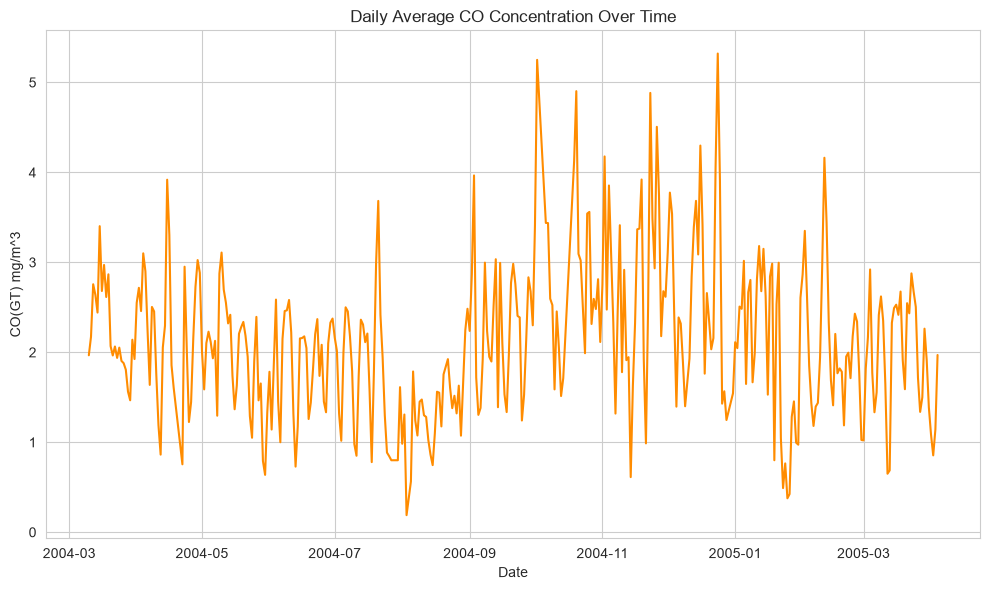

In [11]:
daily_co = clean_data.groupby(clean_data["Datetime"].dt.date)["CO(GT)"].mean()

daily_co.plot(color="darkorange")
plt.title("Daily Average CO Concentration Over Time")
plt.xlabel("Date")
plt.ylabel("CO(GT) mg/m^3")
plt.tight_layout()
plt.show()

## 7. Hourly Pollution Pattern

Grouping by hour of day reveals the daily rhythm of traffic-related pollutants, typically peaking during morning and evening rush hours.

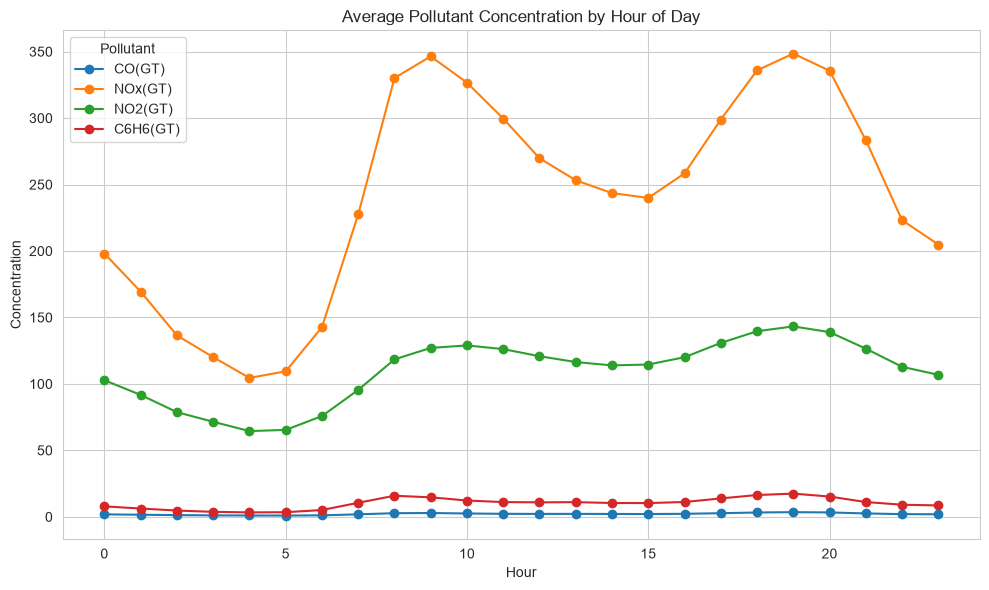

In [12]:
hourly_avg = clean_data.groupby("Hour")[["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)"]].mean()

hourly_avg.plot(marker="o")
plt.title("Average Pollutant Concentration by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Concentration")
plt.legend(title="Pollutant")
plt.tight_layout()
plt.show()

## 8. Monthly Trend of Pollutants

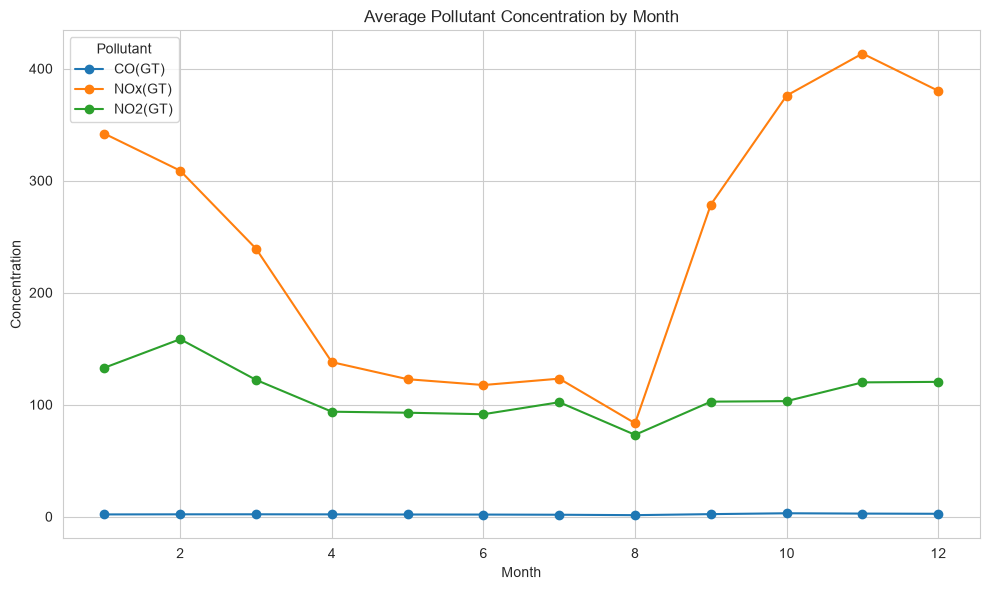

In [13]:
monthly_avg = clean_data.groupby("Month")[["CO(GT)", "NOx(GT)", "NO2(GT)"]].mean()

monthly_avg.plot(marker="o")
plt.title("Average Pollutant Concentration by Month")
plt.xlabel("Month")
plt.ylabel("Concentration")
plt.legend(title="Pollutant")
plt.tight_layout()
plt.show()

## 9. Weekday vs Weekend Pollution Levels

Each day name is mapped to a `Weekday` or `Weekend` category using `match/case`, since it maps a small fixed set of inputs to one of two outcomes.

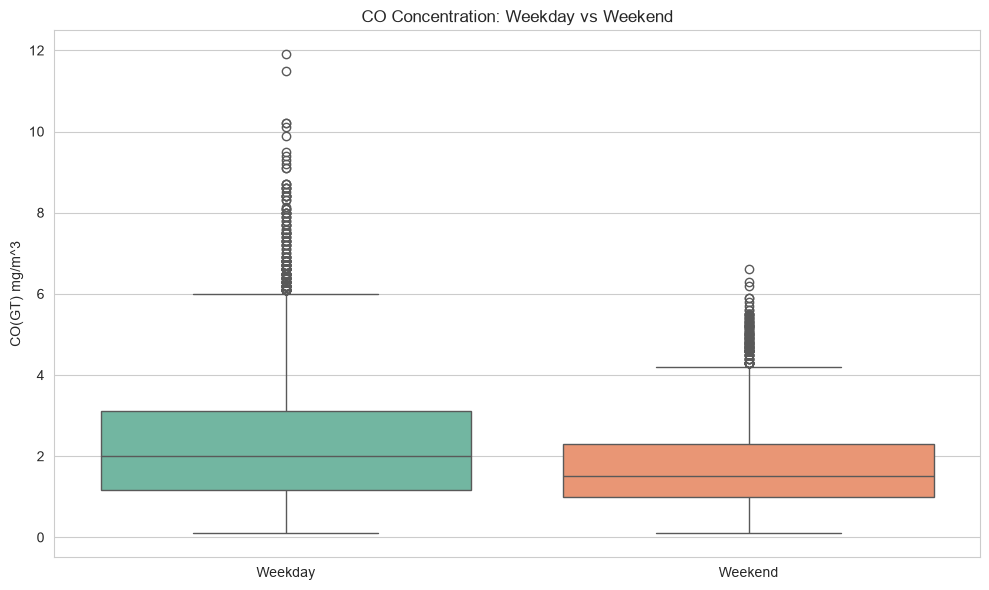

In [14]:
def classify_day_type(day_name):
    match day_name:
        case "Saturday" | "Sunday":
            return "Weekend"
        case _:
            return "Weekday"

clean_data["DayType"] = clean_data["DayOfWeek"].apply(classify_day_type)

sns.boxplot(data=clean_data, x="DayType", y="CO(GT)", hue="DayType", palette="Set2", legend=False)
plt.title("CO Concentration: Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("CO(GT) mg/m^3")
plt.tight_layout()
plt.show()

## 10. Correlation Between Pollutants and Weather Conditions

Correlating pollutant readings with temperature, relative humidity and absolute humidity shows how weather influences pollution levels.

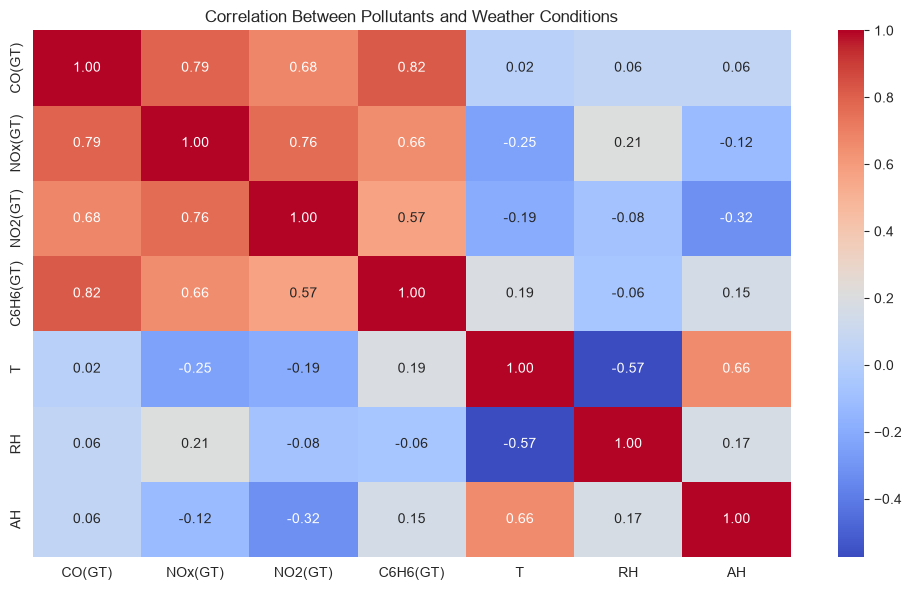

In [15]:
correlation_columns = ["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)", "T", "RH", "AH"]
correlation_matrix = clean_data[correlation_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Pollutants and Weather Conditions")
plt.tight_layout()
plt.show()

## 11. Temperature vs CO Concentration

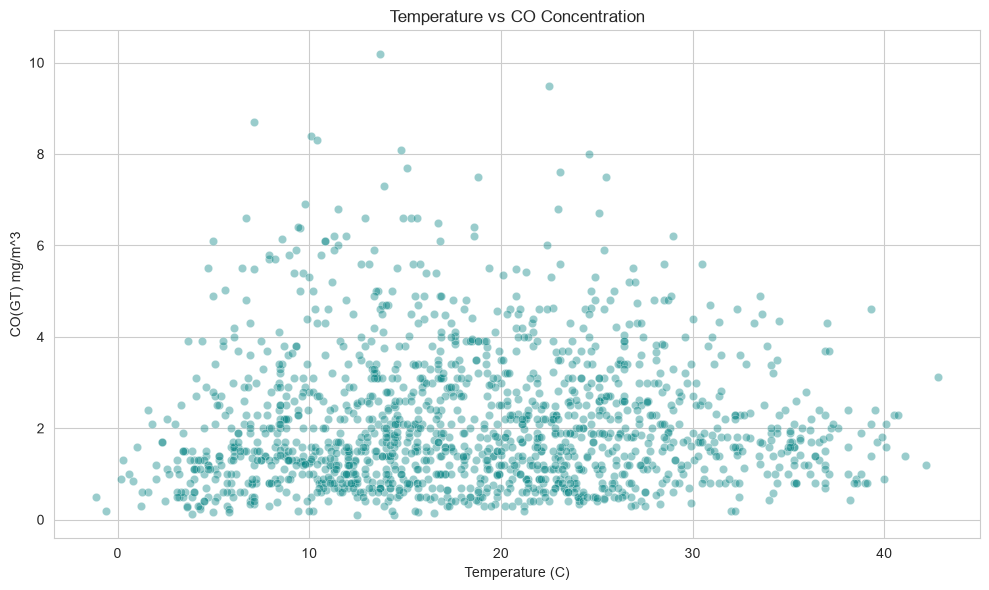

In [16]:
sns.scatterplot(data=clean_data.sample(1500, random_state=42), x="T", y="CO(GT)", alpha=0.4, color="teal")
plt.title("Temperature vs CO Concentration")
plt.xlabel("Temperature (C)")
plt.ylabel("CO(GT) mg/m^3")
plt.tight_layout()
plt.show()

## 12. Humidity vs NO2 Concentration

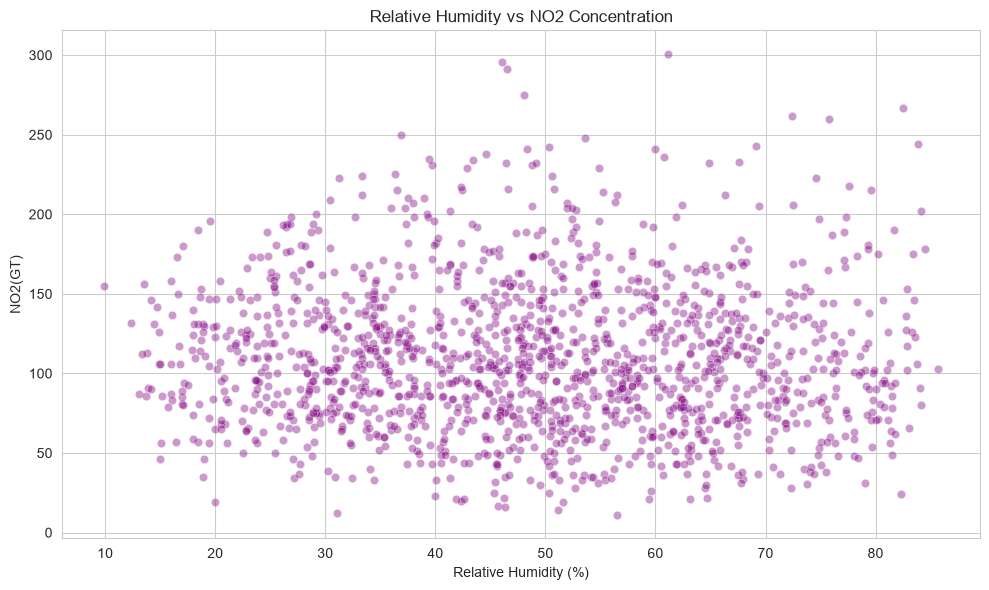

In [17]:
sns.scatterplot(data=clean_data.sample(1500, random_state=42), x="RH", y="NO2(GT)", alpha=0.4, color="purple")
plt.title("Relative Humidity vs NO2 Concentration")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("NO2(GT)")
plt.tight_layout()
plt.show()

## 13. Air Quality Classification

Each hourly CO reading is classified into a `Good`, `Moderate`, `Poor` or `Severe` category using `match/case` with guard conditions, since the outcome depends on which numeric range the value falls into.

In [18]:
def classify_air_quality(co_level):
    match co_level:
        case co if co < 1:
            return "Good"
        case co if co < 2:
            return "Moderate"
        case co if co < 4:
            return "Poor"
        case _:
            return "Severe"

clean_data["AirQualityCategory"] = clean_data["CO(GT)"].apply(classify_air_quality)
category_counts = clean_data["AirQualityCategory"].value_counts().reindex(["Good", "Moderate", "Poor", "Severe"])
category_counts

AirQualityCategory
Good        2004
Moderate    3128
Poor        3175
Severe      1050
Name: count, dtype: int64

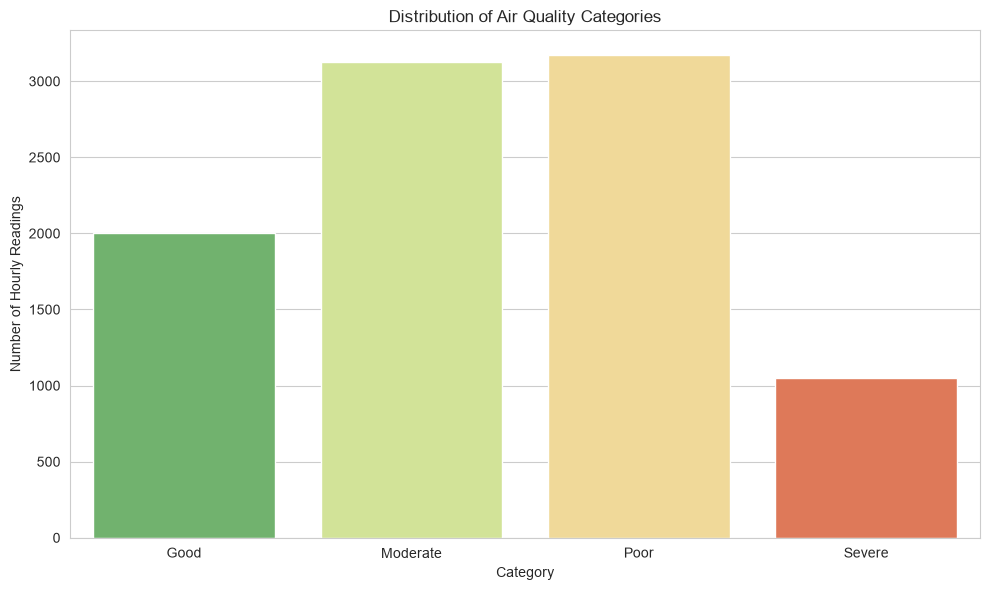

In [19]:
category_order = ["Good", "Moderate", "Poor", "Severe"]

sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, order=category_order, hue_order=category_order, palette="RdYlGn_r", legend=False)
plt.title("Distribution of Air Quality Categories")
plt.xlabel("Category")
plt.ylabel("Number of Hourly Readings")
plt.tight_layout()
plt.show()

## 14. Key Insights

- CO, NOx, NO2 and Benzene concentrations follow a clear **daily rhythm**, peaking during morning and evening traffic hours and dropping to their lowest levels overnight.
- Pollution levels are noticeably **higher on weekdays than weekends**, which lines up with reduced traffic on Saturdays and Sundays.
- **Temperature shows almost no direct correlation with CO**, but it is more clearly negatively correlated with NOx and NO2, suggesting cold, stagnant winter air traps more of those pollutants than warmer weather does.
- **Relative humidity and NO2** show a weak negative relationship in the scatter plot.
- The correlation heatmap shows the different pollutants (CO, NOx, NO2, Benzene) are all **strongly positively correlated with each other**, which makes sense since they mostly come from the same source: vehicle traffic and combustion.
- Under the CO-based classification, **Poor** is the single largest category, closely followed by **Moderate**, with **Good** readings less common and **Severe** readings, typically during peak traffic hours, making up the smallest share.